In [16]:
"""Parse NOAA SRS (Solar Region Summary) text files.

Extracts the "I. Regions with Sunspots" table into a list of dicts,
and converts the Location field (e.g. 'S23E60') into signed
latitude/longitude, matching the sign convention used with
sunpy's HeliographicStonyhurst frame (+lat = North, +lon = West)."""

import re


def parse_location(location_str):
    """Convert e.g. 'S23E60' into (lat=-23, lon=-60)."""
    match = re.match(r"([NS])(\d+)([EW])(\d+)", location_str)
    ns, lat_str, ew, lon_str = match.groups()
    lat = int(lat_str) if ns == "N" else -int(lat_str)
    lon = int(lon_str) if ew == "W" else -int(lon_str)
    return lat, lon


def parse_srs(filepath):
    """Return a list of dicts, one per active region with sunspots."""
    with open(filepath, "r") as f:
        lines = f.readlines()

    regions = []
    in_sunspot_section = False

    for raw_line in lines:
        line = raw_line.strip()

        if line.startswith("I.") and "Regions with Sunspots" in line:
            in_sunspot_section = True
            continue

        if not in_sunspot_section:
            continue

        if line.startswith("IA.") or line.startswith("II.") or line == "":
            break  

        if line.startswith("Nmbr"):
            continue  

        parts = line.split()
        if len(parts) != 8:
            continue  

        nmbr, location, lo, area, z, ll, nn, mag_type = parts
        lat, lon = parse_location(location)

        regions.append({
            "nmbr": nmbr,
            "location": location,
            "lat": lat,
            "lon": lon,
            "carrington_lo": int(lo),
            "area": int(area),
            "z_class": z,
            "ll": int(ll),
            "nn": int(nn),
            "mag_type": mag_type,
        })

    return regions


#if __name__ == "__main__":
    # Teste rápido com um arquivo real
    
    #for r in regioes:regioes = parse_srs(r"D:\IC-DeepLearning\data_srs\20020101SRS.txt")
     #   print(r)
    #print(f"\nTotal de regiões com manchas: {len(regioes)}")

957, 557
923, 378
841, 461
647, 501
450, 292
442, 632
341, 596
706, 663
219, 584
142, 572
114, 329


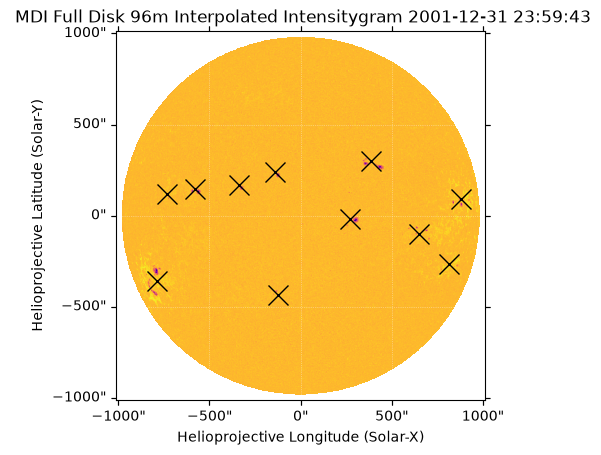

In [ ]:
"""Plot NOAA-cataloged sunspot positions on a SOHO/MDI image.

Takes the regions parsed from a Solar Region Summary (SRS) report and
converts each region's heliographic coordinates (latitude/longitude)
into pixel positions using the image's WCS (via sunpy.map.Map).
Overlays a marker on the corresponding SOHO/MDI continuum image for
each region, to visually validate the coordinate-to-pixel conversion.
"""


import sunpy.map
from sunpy.coordinates import frames
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

mapp = sunpy.map.Map('D:\\IC-DeepLearning\\data_mdi\\mdi.fd_ic_interp.20020101_000000_TAI.continuum.fits')


for r in regioes:regioes = parse_srs(r"D:\IC-DeepLearning\data_srs\20020101SRS.txt")

fig = plt.figure()
ax = fig.add_subplot(projection=mapp)
mapp.plot(axes=ax, cmap="plasma")
for i in regioes:
    coord = SkyCoord(i["lon"]*u.deg, i["lat"]*u.deg, frame=frames.HeliographicStonyhurst, obstime=mapp.date)
    pixel_x, pixel_y = mapp.wcs.world_to_pixel(coord)
    print(f"{pixel_x:.0f}, {pixel_y:.0f}")
    ax.plot(pixel_x, pixel_y, 'x', color='black', markersize=15)  # marca a posição calculada

plt.show()

In [12]:
regioes = parse_srs(r"D:\IC-DeepLearning\data_srs\20020101SRS.txt")
for r in regioes:
    print(r)

{'nmbr': '9751', 'location': 'N04W64', 'lat': 4, 'lon': 64, 'carrington_lo': 142, 'area': 190, 'z_class': 'Eai', 'll': 12, 'nn': 17, 'mag_type': 'Beta-Gamma'}
{'nmbr': '9753', 'location': 'S17W60', 'lat': -17, 'lon': 60, 'carrington_lo': 138, 'area': 60, 'z_class': 'Dso', 'll': 9, 'nn': 10, 'mag_type': 'Beta'}
{'nmbr': '9754', 'location': 'S08W42', 'lat': -8, 'lon': 42, 'carrington_lo': 120, 'area': 70, 'z_class': 'Eai', 'll': 11, 'nn': 20, 'mag_type': 'Beta-Gamma'}
{'nmbr': '9755', 'location': 'S04W16', 'lat': -4, 'lon': 16, 'carrington_lo': 94, 'area': 140, 'z_class': 'Dso', 'll': 4, 'nn': 10, 'mag_type': 'Beta'}
{'nmbr': '9756', 'location': 'S29E08', 'lat': -29, 'lon': -8, 'carrington_lo': 70, 'area': 30, 'z_class': 'Cao', 'll': 3, 'nn': 4, 'mag_type': 'Beta'}
{'nmbr': '9761', 'location': 'N11E08', 'lat': 11, 'lon': -8, 'carrington_lo': 70, 'area': 40, 'z_class': 'Hsx', 'll': 2, 'nn': 1, 'mag_type': 'Alpha'}
{'nmbr': '9763', 'location': 'N07E20', 'lat': 7, 'lon': -20, 'carrington_lo

In [44]:
from datetime import datetime, timedelta
import pandas as pd
file_path = 'output_stream.csv'
first_row = True

start = datetime(2002, 1, 1)
end = datetime(2011, 12, 31)
pace = timedelta(days=1)
finaldata = start

In [ ]:
all_regions = []

while finaldata <= end:
    datanow = finaldata.strftime("%Y-%m-%d")
    path = fr"D:\IC-DeepLearning\data_srs\{finaldata.strftime('%Y%m%d')}SRS.txt"
    finaldata += pace

    try:
        regioes = parse_srs(path)
    except FileNotFoundError:
        continue

    for r in regioes:
        r["date"] = datanow
        all_regions.append(r)

df_final = pd.DataFrame(all_regions)
df_final.to_csv("output_stream.csv", index=False)

In [ ]:
from pathlib import Path
from datetime import datetime, timedelta

start = datetime(2002, 1, 1)
end = datetime(2011, 12, 31)
pace = timedelta(days=1)
finaldata = start

#file_path = Path(fr"D:\IC-DeepLearning\data_mdi\mdi.fd_ic_interp.{finaldata.strftime('%Y%m%d')}_000000_TAI.continuum.fits")
total = 0
while finaldata <= end:
    datanow = finaldata.strftime("%Y-%m-%d")
    file_path = Path(fr"D:\IC-DeepLearning\data_mdi\mdi.fd_ic_interp.{finaldata.strftime('%Y%m%d')}_000000_TAI.continuum.fits")

    if not file_path.is_file():
        print(f"o arquivo do dia {datanow} não existe!")
        total += 1

    finaldata += pace

print(total)

o arquivo do dia 2002-02-06 não existe!
o arquivo do dia 2002-02-07 não existe!
o arquivo do dia 2002-02-08 não existe!
o arquivo do dia 2002-02-09 não existe!
o arquivo do dia 2002-02-10 não existe!
o arquivo do dia 2002-02-11 não existe!
o arquivo do dia 2002-02-12 não existe!
o arquivo do dia 2002-02-13 não existe!
o arquivo do dia 2003-05-26 não existe!
o arquivo do dia 2003-06-28 não existe!
o arquivo do dia 2003-06-29 não existe!
o arquivo do dia 2003-06-30 não existe!
o arquivo do dia 2003-07-01 não existe!
o arquivo do dia 2003-07-02 não existe!
o arquivo do dia 2003-07-03 não existe!
o arquivo do dia 2003-07-04 não existe!
o arquivo do dia 2003-07-05 não existe!
o arquivo do dia 2003-07-06 não existe!
o arquivo do dia 2003-07-07 não existe!
o arquivo do dia 2003-07-08 não existe!
o arquivo do dia 2003-07-09 não existe!
o arquivo do dia 2003-07-10 não existe!
o arquivo do dia 2003-07-16 não existe!
o arquivo do dia 2003-08-14 não existe!
o arquivo do dia 2003-09-30 não existe!


In [ ]:
import drms

client = drms.Client(email="andrei2legal@gmail.com")
result = client.query("mdi.fd_Ic_interp[2011.01.01_TAI-2011.01.31_TAI@1d]{continuum}", key="T_REC")
print(len(result))
print(result)

0
Empty DataFrame
Columns: []
Index: []


In [ ]:
#NEW CSV

import pandas as pd
import sunpy.map
from sunpy.coordinates import frames
from astropy.coordinates import SkyCoord
import astropy.units as u
from pathlib import Path

df_srs = pd.read_csv("output_stream.csv")

df_srs["pixel_x"] = None
df_srs["pixel_y"] = None

for data, group in df_srs.groupby("date"):
    data_fmt = data.replace("-", "")
    path_image = Path(fr"D:\IC-DeepLearning\data_mdi\mdi.fd_ic_interp.{data_fmt}_000000_TAI.continuum.fits")

    if not path_image.is_file():
        continue

    mapp = sunpy.map.Map(str(path_image))

    for indx, linha in group.iterrows():
        coord = SkyCoord(linha["lon"] * u.deg, linha["lat"] * u.deg,
                          frame=frames.HeliographicStonyhurst, obstime=mapp.date)
        pixel_x, pixel_y = mapp.wcs.world_to_pixel(coord)
        df_srs.at[indx, "pixel_x"] = float(pixel_x)
        df_srs.at[indx, "pixel_y"] = float(pixel_y)

df_srs.to_csv("output_stream_wpixel.csv", index=False)
print("Finished.")


Concluído.
